# General single-fish calcium analysis - reusable notebook

Short orchestration notebook derived from `Exp_7_trans_stat.ipynb`. Reusable loading, analysis, plotting, and significant-trace helpers live in `src/`; this notebook keeps only experiment choices and display cells.


In [197]:
# Cell 01 - Setup imports
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.plotting as plott
import src.data_loading as exio
import src.analysis_tools as at
from src.significant_traces import (
    clean_binary_raster_columns,
    plot_dff_and_raster,
)
from src.significant_traces_v2 import compute_noise_model_romano_fast_modular as compute_significant_traces

plt.style.use("default")
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [198]:
# Cell 02 - USER SETTINGS

# Experiment identity and paths. Used by Cell 03 when loading the experiment bundle.
fish_id = "L800_f11"
experiment_name = "Exp_8_accumulation_ev"
main_path = Path("D:/Alejandro/Data/OneDrive - Universit\u00e9 de Lausanne/Lab/Data/2p")
stimuli_main_path = Path("D:/Alejandro/Data/OneDrive - Universit\u00e9 de Lausanne/Lab/Data/stimuli")
selected_blocks = [f"B{n}" for n in range(1, 5)]
fps_2p = 2.0

# Z-score baseline settings. Used by Cell 04 to compute and save z-score traces.
zscore_t_pre_s = 5.0
zscore_t_post_s = 27.0
zscore_baseline_s = 10.0

# Trial-aligned trace settings. Used by Cells 08-11 for mean traces and reliability filtering.
trial_t_pre_s = 5.0
trial_t_post_s = 27.0

# Sorted chunk plot settings. Used by Cells 07, 10, and 16.
window_pre = 5
window_post = 17
stimuli_order_ids = [5,4,3,2,1,8,7,6,16,15,14,13,12,11,10,9]# [14, 9, 11, 13, 4, 6, 2, 7, 8, 10, 12, 3, 5, 1]
sort_mode = "corravg"
sort_n_clusters = 5
binary_sort_n_clusters = 4
random_state = 42
average_across_repeats = False
binary_average_across_repeats = True

# Reliability filter settings. Used by Cell 10 and saved to filtered_neurons_by_stimuli.
reliability_threshold = 0.4
make_reliability_plots = True
save_reliability_indices = True
reliability_folder_name = "filtered_neurons_by_stimuli"

# Mean-trace plot settings. Used by Cells 09 and 11.
save_mean_trace_plots = False
mean_trace_comment = "all_stimuli"
mean_trace_dpi = 600

# Significant-trace settings. Used by Cells 12-15. The notebook uses the V2 detector only.
sig_n_bins = 1200
sig_k_neighbors = 100
sig_conf_cutoff = 90
sig_random_state = 0
sig_plot_odds = False
sig_tau_decay = 6.0
sig_vmax_dff = 0.05


In [199]:
# Cell 03 - Load experiment bundle
# Loads dFoF, stimulus timing, cached outputs when available, and metadata paths.
importlib.reload(exio)

loaded = exio.load_2p_experiment(
    fish_id=fish_id,
    experiment_name=experiment_name,
    main_path=main_path,
    stimuli_main_path=stimuli_main_path,
    fps_2p=fps_2p,
    selected_blocks=selected_blocks,
)

dfof = loaded["dfof"]
stimuli_durations = loaded["stimuli_durations"]
exp_log = loaded["adjusted_log"]
stimuli_trace_60 = loaded["stimuli_trace_60"]
stimuli_table = loaded["stimuli_table"]
stimuli_id_map = loaded["stimuli_id_map"]
duration_2p_block_sec = loaded["duration_2p_block_sec"]
frames_per_block = loaded["frames_per_block"]
paths = loaded["paths"]
raster = loaded["raster"]
dfof_center = loaded["deltaF_center"]
dFoF_merged_map = loaded["dFoF_merged_map"]
plane_ids = loaded["plane_ids"]
mean_imgs = loaded["mean_imgs"]
stat_per_plane = loaded["stat_per_plane"]

print(f"Loaded dFoF shape: {dfof.shape}")
print(f"Plots path: {paths['plots_path']}")


Significant traces file not found (skipping): D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f11_Exp_8_accumulation_ev\03_analysis\functional\plots\significant_traces\L800_f11_significant_traces.npz
kept_neuron_indices file not found (skipping): D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f11_Exp_8_accumulation_ev\03_analysis\functional\plots\filtered_neurons_by_stimuli\L800_f11_kept_neuron_indices.npy
Loaded filtered_roi_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f11_Exp_8_accumulation_ev\03_analysis\functional\suite2P\merged_dFoF\L800_f11_dFoF_merged_filtered_roi_indices.npy
z_core file not found (skipping): D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f11_Exp_8_accumulation_ev\03_analysis\functional\plots\z_core\L800_f11_zcore.npz
Using canonical merged map file: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f11_Exp_8_accumulation_ev\03_analysis\functi

In [200]:
# Cell 04 - Compute z-score traces and save cache
# Uses zscore_* settings from Cell 02 and writes z_core/{prefix}_zcore.npz.
z_align = at.build_trial_aligned_traces(
    dfof=dfof,
    stimuli_trace_60=stimuli_trace_60,
    fps_2p=fps_2p,
    t_pre_s=zscore_t_pre_s,
    t_post_s=zscore_t_post_s,
    stimuli_id_map=stimuli_id_map,
    verbose=True,
)

zres = at.zscore_dfof_from_prestim_baseline(
    dfof=dfof,
    onsets_by_id=z_align["onsets_by_id"],
    fps_2p=fps_2p,
    baseline_s=zscore_baseline_s,
    assume_time_by_neuron=True,
    verbose=True,
)

z_traces = zres["z_traces"]
prefix = paths["prefix"]
folder_zcore = paths["plots_path"] / "z_core"
folder_zcore.mkdir(parents=True, exist_ok=True)
out_zcore = folder_zcore / f"{prefix}_zcore.npz"

np.savez(
    out_zcore,
    z_traces=zres["z_traces"],
    baseline_mean=zres["baseline_mean"],
    baseline_std=zres["baseline_std"],
    valid_onsets=zres["valid_onsets"],
)

print(f"Saved z_traces to {out_zcore}")


Number of neurons: 1778
Number of time points: 5424
2p duration (s): 2712.0
60Hz duration from data (s): 2708.15
Output stim trace shape: (5424,)
Stimuli IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Stimuli names: ['LeBseg135', 'LeBseg1rnd', 'LeBseg1', 'LeBseg2', 'LeB', 'Leflick1', 'Leflick5', 'LeRock', 'RiBflick1', 'RiBflick5', 'RiBrock', 'RiBseg135', 'RiBseg1rnd', 'RiBseg1', 'RiBseg2', 'RiB']
stim 1: 4 onsets | kept 4 trials | dropped 0
stim 2: 4 onsets | kept 4 trials | dropped 0
stim 3: 4 onsets | kept 4 trials | dropped 0
stim 4: 4 onsets | kept 4 trials | dropped 0
stim 5: 4 onsets | kept 4 trials | dropped 0
stim 6: 4 onsets | kept 4 trials | dropped 0
stim 7: 4 onsets | kept 4 trials | dropped 0
stim 8: 4 onsets | kept 4 trials | dropped 0
stim 9: 4 onsets | kept 4 trials | dropped 0
stim 10: 4 onsets | kept 4 trials | dropped 0
stim 11: 4 onsets | kept 4 trials | dropped 0
stim 12: 4 onsets | kept 4 trials | dropped 0
stim 13: 4 onsets | kept 4 trials | dropped

In [201]:
# Cell 05 - Stimulus styles and selected plot order
# Uses stimuli_order_ids from Cell 02 and prepares color/linestyle maps for all later plots.
stimuli_names_from_files = plott.list_stimulus_names(paths["stimuli_path"])
stimuli_colors, stimuli_linestyles = plott.build_stimulus_style_maps(
    stimuli_names=stimuli_names_from_files,
)

print(dict(sorted(stimuli_id_map.items(), key=lambda item: item[1])))

id_to_stimulus = {idx: name for name, idx in stimuli_id_map.items()}
missing_ids = [idx for idx in stimuli_order_ids if idx not in id_to_stimulus]
if missing_ids:
    raise ValueError(f"Unknown stimulus ids: {missing_ids}")

stimuli_ordered = [id_to_stimulus[idx] for idx in stimuli_order_ids]

print("Using colors for:", experiment_name)
print(stimuli_names_from_files)
print(stimuli_ordered)
print(stimuli_linestyles)


{'LeBseg135': 1, 'LeBseg1rnd': 2, 'LeBseg1': 3, 'LeBseg2': 4, 'LeB': 5, 'Leflick1': 6, 'Leflick5': 7, 'LeRock': 8, 'RiBflick1': 9, 'RiBflick5': 10, 'RiBrock': 11, 'RiBseg135': 12, 'RiBseg1rnd': 13, 'RiBseg1': 14, 'RiBseg2': 15, 'RiB': 16}
Using colors for: Exp_8_accumulation_ev
['LeB', 'LeBseg1', 'LeBseg1rnd', 'LeBseg2', 'LeBseg135', 'Leflick1', 'Leflick5', 'LeRock', 'RiB', 'RiBflick1', 'RiBflick5', 'RiBrock', 'RiBseg1', 'RiBseg1rnd', 'RiBseg2', 'RiBseg135']
['LeB', 'LeBseg2', 'LeBseg1', 'LeBseg1rnd', 'LeBseg135', 'LeRock', 'Leflick5', 'Leflick1', 'RiB', 'RiBseg2', 'RiBseg1', 'RiBseg1rnd', 'RiBseg135', 'RiBrock', 'RiBflick5', 'RiBflick1']
{'LeB': '-', 'LeBseg1': '-', 'LeBseg1rnd': '-', 'LeBseg2': '-', 'LeBseg135': '-', 'Leflick1': '-', 'Leflick5': '-', 'LeRock': '-', 'RiB': '--', 'RiBflick1': '--', 'RiBflick5': '--', 'RiBrock': '--', 'RiBseg1': '--', 'RiBseg1rnd': '--', 'RiBseg2': '--', 'RiBseg135': '--'}


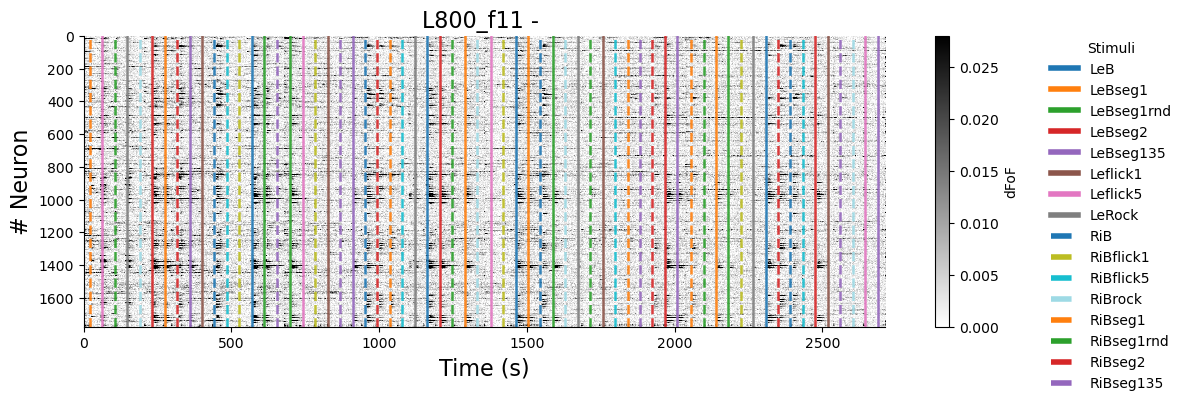

In [202]:
# Cell 06 - Full dFoF raster with stimulus markers
# Uses raw dFoF from Cell 03 and style maps from Cell 05.
fig, ax = plt.subplots(figsize=(12, 4))

im = plott.raster_with_stimuli(
    ax=ax,
    data=dfof,
    fps=fps_2p,
    fish_id=fish_id,
    vmax=None,
)

legend_handles = plott.add_stimuli_markers(
    ax,
    exp_log,
    stimuli_durations,
    stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
)
ax.legend(
    handles=legend_handles,
    title="Stimuli",
    bbox_to_anchor=(1.2, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False,
)
ax.set_xlabel("Time (s)")
fig.colorbar(im, ax=ax, label="dFoF")
fig.tight_layout()
plt.show()


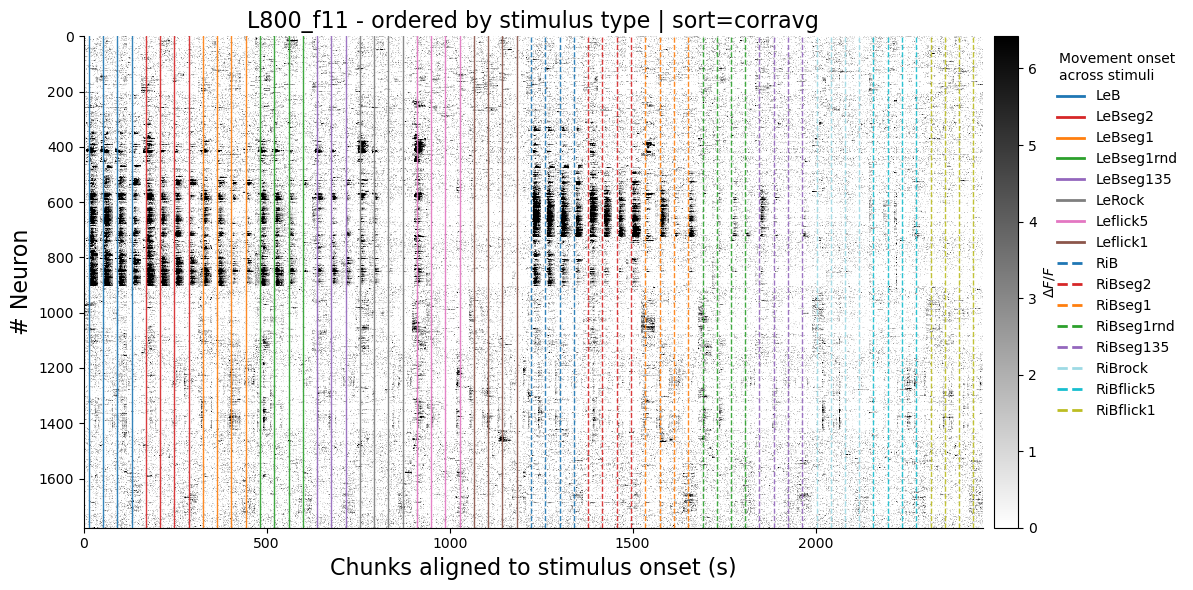

In [203]:
# Cell 07 - Sorted z-score chunks, all neurons
# Uses z_traces from Cell 04 and sorted chunk settings from Cell 02.
fig, ax, order_z_all = plott.plot_sorted_chunks_single_mode(
    dfof=z_traces,
    exp_log=exp_log,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    stimuli_ordered=stimuli_ordered,
    fps_2p=fps_2p,
    window_pre=window_pre,
    window_post=window_post,
    sort_mode=sort_mode,
    n_clusters=sort_n_clusters,
    random_state=random_state,
    average_across_repeats=average_across_repeats,
    fish_id=fish_id,
    neuron_order=None,
    sort_label=None,
    vmax=None,
)
plt.show()


In [204]:
# Cell 08 - Build trial-aligned z-score traces
# Uses trial_t_* settings from Cell 02; outputs feed mean traces and reliability filtering.
trial_res = at.build_trial_aligned_traces(
    dfof=z_traces,
    stimuli_trace_60=stimuli_trace_60,
    fps_2p=fps_2p,
    t_pre_s=trial_t_pre_s,
    t_post_s=trial_t_post_s,
    stimuli_id_map=stimuli_id_map,
    verbose=True,
)

trial_aligned_traces = trial_res["trial_aligned_traces"]
stimuli_ids = trial_res["stimuli_ids"]
stimuli_names = trial_res["stimuli_names"]
win_length = trial_res["win_length"]
stimuli_trace = trial_res["stimuli_trace"]
onsets_by_id = trial_res["onsets_by_id"]


Number of neurons: 1778
Number of time points: 5424
2p duration (s): 2712.0
60Hz duration from data (s): 2708.15
Output stim trace shape: (5424,)
Stimuli IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Stimuli names: ['LeBseg135', 'LeBseg1rnd', 'LeBseg1', 'LeBseg2', 'LeB', 'Leflick1', 'Leflick5', 'LeRock', 'RiBflick1', 'RiBflick5', 'RiBrock', 'RiBseg135', 'RiBseg1rnd', 'RiBseg1', 'RiBseg2', 'RiB']
stim 1: 4 onsets | kept 4 trials | dropped 0
stim 2: 4 onsets | kept 4 trials | dropped 0
stim 3: 4 onsets | kept 4 trials | dropped 0
stim 4: 4 onsets | kept 4 trials | dropped 0
stim 5: 4 onsets | kept 4 trials | dropped 0
stim 6: 4 onsets | kept 4 trials | dropped 0
stim 7: 4 onsets | kept 4 trials | dropped 0
stim 8: 4 onsets | kept 4 trials | dropped 0
stim 9: 4 onsets | kept 4 trials | dropped 0
stim 10: 4 onsets | kept 4 trials | dropped 0
stim 11: 4 onsets | kept 4 trials | dropped 0
stim 12: 4 onsets | kept 4 trials | dropped 0
stim 13: 4 onsets | kept 4 trials | dropped

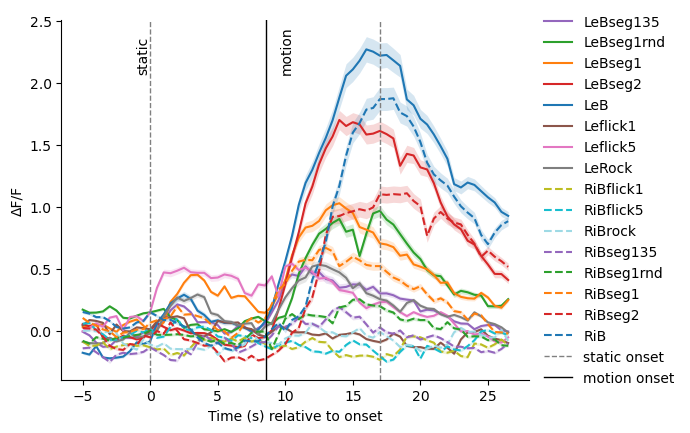

In [205]:
# Cell 09 - Mean traces and response metrics, all neurons
# Uses trial_aligned_traces from Cell 08; plots all neurons before reliability filtering.
metrics_all = at.compute_trial_mean_response_metrics(
    trial_aligned_traces=trial_aligned_traces,
    stimuli_ids=stimuli_ids,
    fps_2p=fps_2p,
    t_pre_s=trial_t_pre_s,
    t_post_s=trial_t_post_s,
)

mean_traces = metrics_all["mean_traces"]
peaks = metrics_all["peaks"]
aucs = metrics_all["aucs"]
averages = metrics_all["averages"]

fig_mean_all, ax_mean_all, used_colors_all, out_path_all = plott.plot_stimulus_means(
    mean_traces=mean_traces,
    stimuli_ids=stimuli_ids,
    stimuli_names=stimuli_names,
    title_prefix="",
    fps_2p=fps_2p,
    t_post_s=trial_t_post_s,
    t_pre_s=trial_t_pre_s,
    stimuli_durations=stimuli_durations,
    plots_path=paths["plots_path"],
    prefix=paths["prefix"],
    dpi=mean_trace_dpi,
    save=save_mean_trace_plots,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    close_after=False,
    kept_cells=None,
    comment=mean_trace_comment,
)


Saved kept neuron indices to: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f11_Exp_8_accumulation_ev\03_analysis\functional\plots\filtered_neurons_by_stimuli\L800_f11_kept_neuron_indices.npy


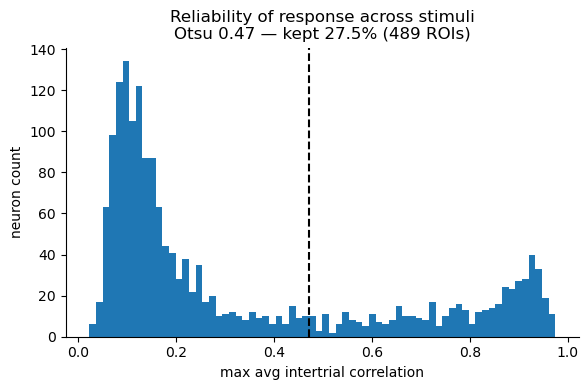

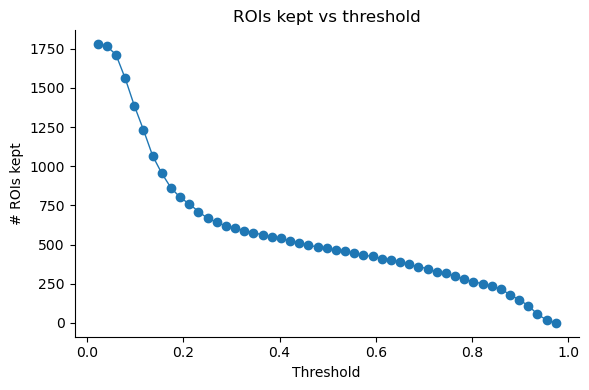

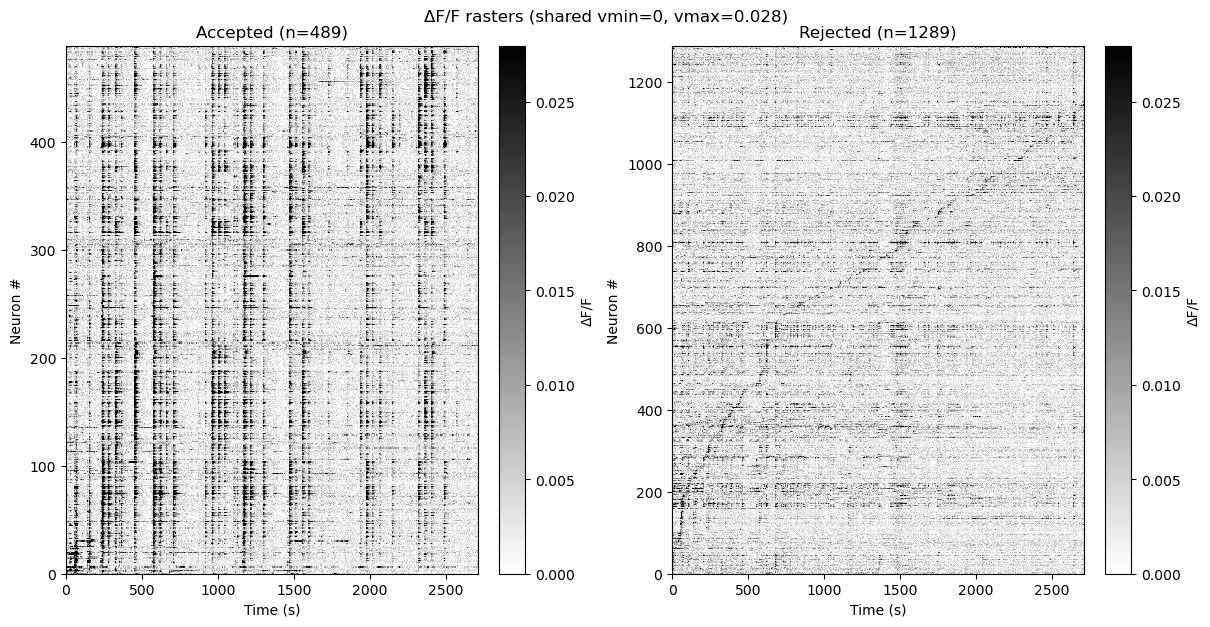

Kept 489 neurons after reliability filtering.


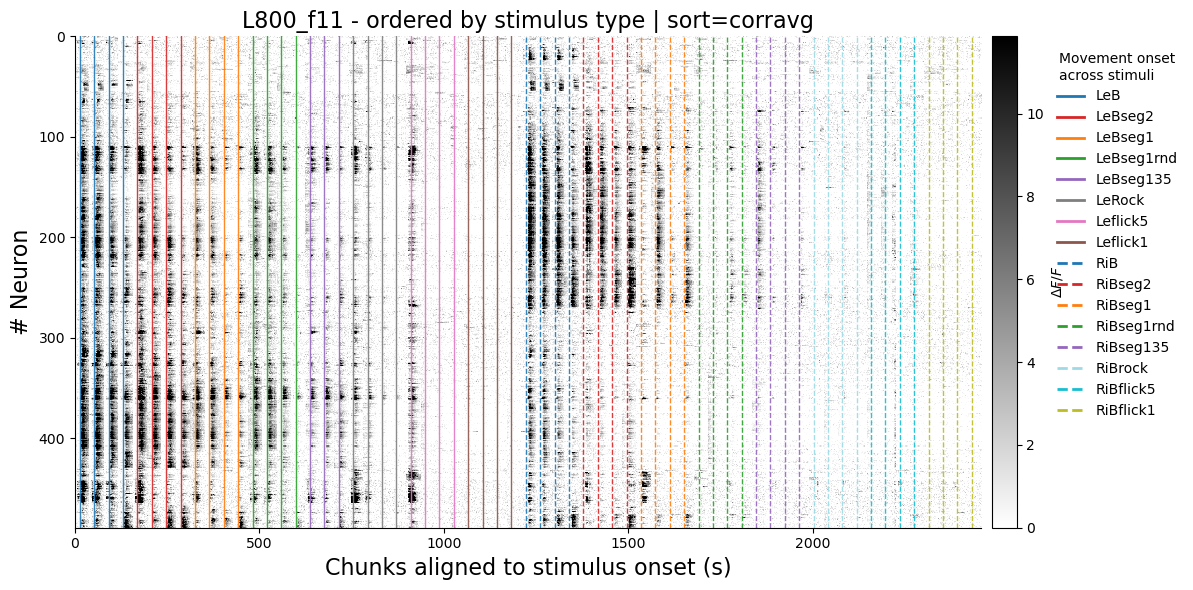

In [206]:
# Cell 10 - Reliability filtering and filtered sorted chunks
# Uses reliability settings from Cell 02; saves kept neuron indices when enabled.
reliability_results = at.filter_neurons_by_trial_reliability(
    dfof=dfof,
    trial_aligned_traces=trial_aligned_traces,
    stimuli_ids=stimuli_ids,
    fps_2p=fps_2p,
    plots_path=paths["plots_path"],
    prefix=paths["prefix"],
    custom_threshold=None,#reliability_threshold,
    folder_name=reliability_folder_name,
    make_plots=make_reliability_plots,
    save_indices=save_reliability_indices,
)

kept_neuron_indices = reliability_results["kept_neuron_indices"]
print(f"Kept {len(kept_neuron_indices)} neurons after reliability filtering.")

fig_z_kept, ax_z_kept, order_z_kept = plott.plot_sorted_chunks_single_mode(
    dfof=z_traces[:, kept_neuron_indices],
    exp_log=exp_log,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    stimuli_ordered=stimuli_ordered,
    fps_2p=fps_2p,
    window_pre=window_pre,
    window_post=window_post,
    sort_mode=sort_mode,
    n_clusters=sort_n_clusters,
    random_state=random_state,
    average_across_repeats=average_across_repeats,
    fish_id=fish_id,
    neuron_order=None,
    sort_label=None,
)
plt.show()


✅ Saved: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f11_Exp_8_accumulation_ev\03_analysis\functional\plots\L800_f11_dfof_as_func_of_time_L.png


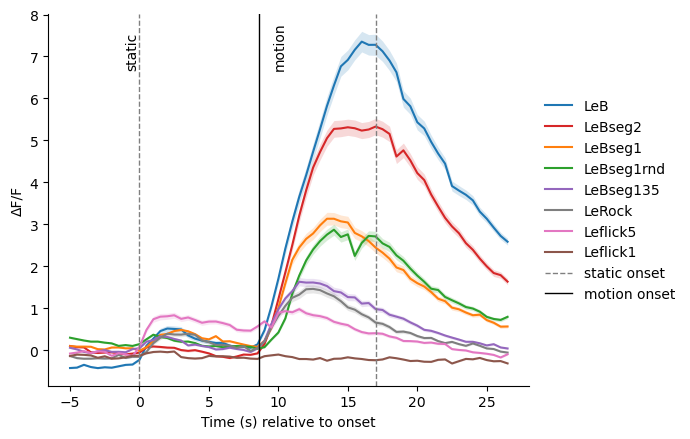

In [215]:
# Cell 11 - Mean traces and response metrics, filtered neurons only
# Reuses trial_aligned_traces from Cell 08 and kept_neuron_indices from Cell 10.
metrics_kept = at.compute_trial_mean_response_metrics(
    trial_aligned_traces=trial_aligned_traces,
    stimuli_ids=stimuli_ids,
    fps_2p=fps_2p,
    t_pre_s=trial_t_pre_s,
    t_post_s=trial_t_post_s,
    kept_neuron_indices=kept_neuron_indices,
)

mean_traces_kept = metrics_kept["mean_traces"]
peaks_kept = metrics_kept["peaks"]
aucs_kept = metrics_kept["aucs"]
averages_kept = metrics_kept["averages"]

# Editable subset for this plot.
# Use None to plot all stimuli in the raster order, or use IDs/names, e.g. [5, 4, 3] or ["LeB", "LeBseg2"].
mean_trace_stimuli_subset =[5,4,3,2,1,8,7,6]#[16,15,14,13,12,11,10,9]#[5,4,3,2,1,8,7,6]##[5,4,3,2,1,8,7,6]#[16,15,14,13,12,11,10,9]##[16,15,14,13,12,11,10,9]#[5,4,3,2,1,8,7,6]# 

if mean_trace_stimuli_subset is None:
    mean_trace_plot_order = stimuli_order_ids
else:
    resolved = at.resolve_selected_stimuli(
        selected_stimuli=mean_trace_stimuli_subset,
        stimuli_id_map=stimuli_id_map,
        available_stimuli=mean_traces_kept.keys(),
    )
    mean_trace_plot_order = resolved["stimulus_ids"]

mean_plot_ids_kept = [idx for idx in mean_trace_plot_order if idx in mean_traces_kept]
mean_plot_names_kept = [id_to_stimulus[idx] for idx in mean_plot_ids_kept]

fig_mean_kept, ax_mean_kept, used_colors_kept, out_path_kept = plott.plot_stimulus_means(
    mean_traces=mean_traces_kept,
    stimuli_ids=mean_plot_ids_kept,
    stimuli_names=mean_plot_names_kept,
    title_prefix="",
    fps_2p=fps_2p,
    t_post_s=trial_t_post_s,
    t_pre_s=trial_t_pre_s,
    stimuli_durations=stimuli_durations,
    plots_path=paths["plots_path"],
    prefix=paths["prefix"],
    dpi=mean_trace_dpi,
    save=True,#save_mean_trace_plots,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    close_after=False,
    kept_cells=None,
    comment="L",
)


In [208]:
# Cell 12 - Significant-trace input preparation
# Plot significant traces only - filtered neurons only
# Compute significant traces using the modified Romano et al. method
dfof_kept = dfof[:, kept_neuron_indices]


[Noise Fit] Used fallback on 0 out of 489 ROIs (0.0%)
Saved V2 significant traces to D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L800_f11_Exp_8_accumulation_ev\03_analysis\functional\plots\significant_traces\L800_f11_significant_traces.npz


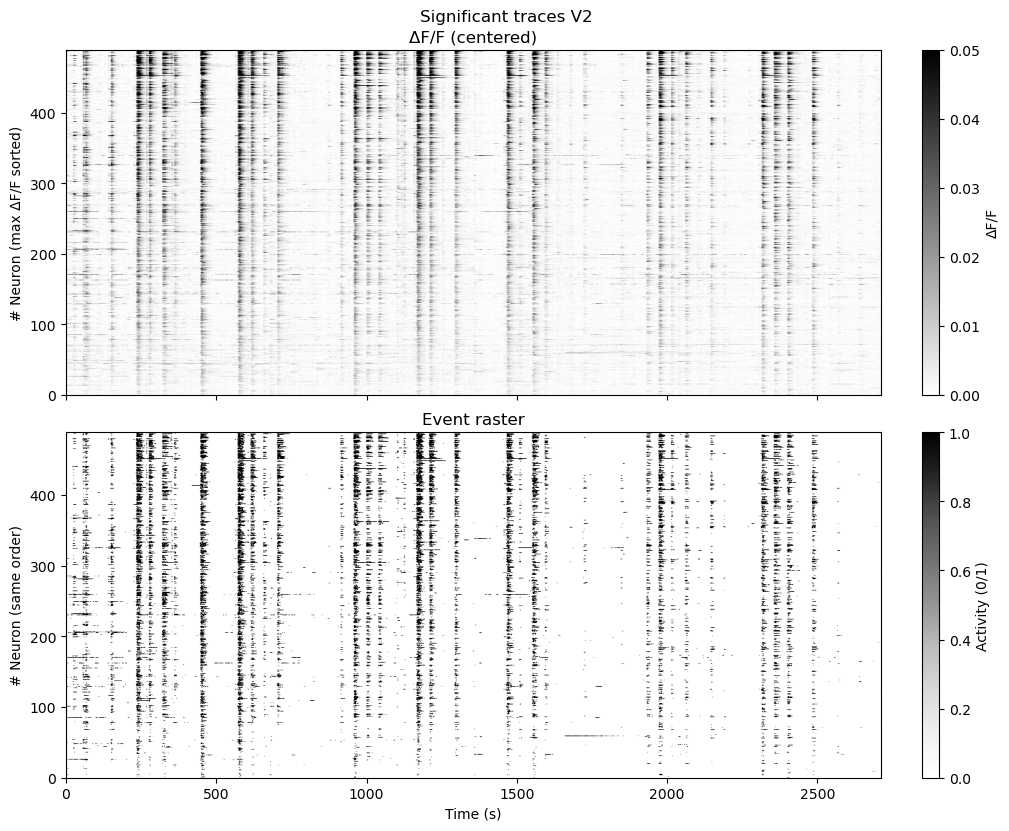

In [216]:
# Cell 13 - V2 significant traces, canonical save, and diagnostic plot
# Runs the V2 Romano-style detector and writes significant_traces/{prefix}_significant_traces.npz.

sig_n_bins = 2200
sig_k_neighbors = 100
sig_conf_cutoff = 90

(
    mapOfOdds,
    deltaF_center,
    density_data,
    density_noise,
    xev,
    yev,
    raster,
    mapOfOddsJoint,
) = compute_significant_traces(
    dfof_kept,
    n_bins=sig_n_bins,
    k_neighbors=sig_k_neighbors,
    confCutOff=sig_conf_cutoff,
    plot_odds=sig_plot_odds,
    fps=fps_2p,
    tauDecay=sig_tau_decay,
    random_state=sig_random_state,
)

folder_raster = paths["plots_path"] / "significant_traces"
folder_raster.mkdir(parents=True, exist_ok=True)
out_raster = folder_raster / f"{paths['prefix']}_significant_traces.npz"
np.savez(
    out_raster,
    raster=raster,
    deltaF_center=deltaF_center,
)

print(f"Saved V2 significant traces to {out_raster}")
sort_idx = plot_dff_and_raster(
    deltaF_center,
    raster,
    fps=fps_2p,
    vmax_dff=sig_vmax_dff,
    title="Significant traces V2",
)


In [210]:
# Cell 14 - V1 removed from notebook workflow
# The reusable notebook now uses only the V2 significant-trace detector in Cell 13.
# V1 remains available in src/significant_traces.py for legacy comparisons if needed.
print("V1 significant-trace computation is skipped; canonical raster comes from Cell 13 V2 output.")


V1 significant-trace computation is skipped; canonical raster comes from Cell 13 V2 output.


In [211]:
# Cell 15 - Clean significant raster columns before correlation sorting
# Removes neurons with NaN values or zero variance, matching the original sanity-check step.
raster_clean_results = clean_binary_raster_columns(raster)
raster_clean = raster_clean_results["raster_clean"]
nan_mask = raster_clean_results["nan_mask"]
zero_var_mask = raster_clean_results["zero_var_mask"]
bad_mask = raster_clean_results["bad_mask"]

print("Neurons with any NaN:", np.where(nan_mask)[0])
print("Neurons with zero variance:", np.where(zero_var_mask)[0])
print("Total bad neurons:", int(np.sum(bad_mask)), "out of", raster.shape[1])


Neurons with any NaN: []
Neurons with zero variance: [  6  17  51 147 148 195 269 277 388 398 427]
Total bad neurons: 11 out of 489


[corravg] Ignorando 55 neuronas con NaN/Inf o varianza 0 para el ordenado.


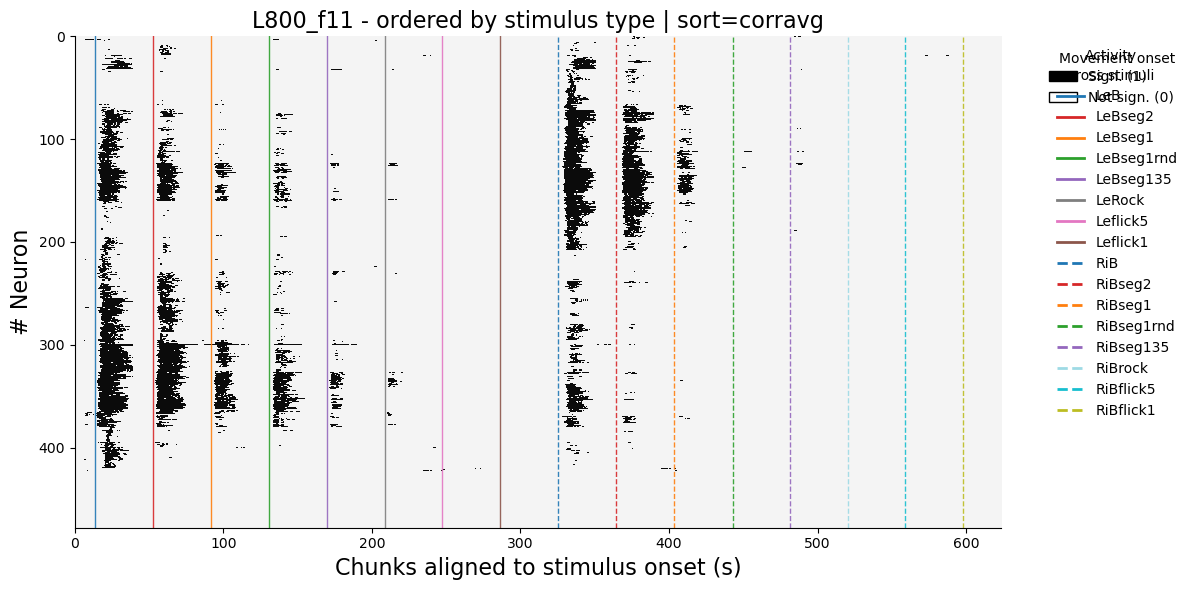

In [212]:
# Cell 16 - Sorted significant binary raster chunks
# Uses cleaned binary raster from Cell 15 and binary sort settings from Cell 02.
fig_binary, ax_binary, order_binary = plott.plot_sorted_chunks_single_mode(
    dfof=raster_clean,
    exp_log=exp_log,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    stimuli_ordered=stimuli_ordered,
    fps_2p=fps_2p,
    window_pre=window_pre,
    window_post=window_post,
    sort_mode=sort_mode,
    n_clusters=binary_sort_n_clusters,
    random_state=random_state,
    average_across_repeats=binary_average_across_repeats,
    fish_id=fish_id,
    neuron_order=None,
    sort_label=None,
    is_binary=True,
)
plt.show()
